In [125]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
from interpret.perf import ROC
from interpret.glassbox import LogisticRegression

# 1.Databetes

## 1-1 載入資料

In [126]:
df = pd.read_csv("../data/diabetes.csv")

cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'DiabetesPedigreeFunction', 'BMI']
    
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1-2 分割特徵與標籤

In [127]:
y_d = df["Outcome"]
X_d = df.drop(columns=["Outcome"])

## 1-3 訓練/測試分割

In [128]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42
)

In [129]:
import numpy as np

X_train_d[cols] = X_train_d[cols].replace(0, np.nan)
X_test_d[cols] = X_test_d[cols].replace(0, np.nan)

for c in cols:
    median = X_train_d[c].median()
    X_train_d[c] = X_train_d[c].fillna(median)
    X_test_d[c] = X_test_d[c].fillna(median)

## 1-4 資料探索

In [130]:
from interpret.data import ClassHistogram

hist_diabetes = ClassHistogram().explain_data(X_train_d, y_train_d, name='daibetes')
show(hist_diabetes)

<!-- http://127.0.0.1:7243/6289898720/ -->

## 1-4 訓練 EBM

In [131]:
from interpret.glassbox import ExplainableBoostingClassifier

ebm = ExplainableBoostingClassifier(random_state=42)
ebm.fit(X_train_d, y_train_d)

,feature_names,None
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,'3x'
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.015
,greedy_ratio,10.0


## 1-5 效能評估/計算AUC

In [132]:
ebm_perf = ROC(ebm).explain_perf(X_test_d, y_test_d, name='EBM')
show(ebm_perf)

<!-- http://127.0.0.1:7243/6285350016/ -->

In [133]:
y_prob_d = ebm.predict_proba(X_test_d)[:, 1]
auc = roc_auc_score(y_test_d, y_prob_d)
print(f"EBM Test AUC:{auc:.3f}")

EBM Test AUC:0.827


## 1-6 全域解釋

In [134]:
ebm_global = ebm.explain_global()
show(ebm_global)

<!-- http://127.0.0.1:7243/6290963152/ -->

## 1-7 局部解釋

In [135]:
ebm_local = ebm.explain_local(X_test_d[:5], y_test_d[:5])
show(ebm_local, 0)

<!-- http://127.0.0.1:7243/6292960336/ -->

# 2.Heart

## 2-1 載入資料+前處理

In [136]:
import pandas as pd
from interpret.glassbox import ExplainableBoostingClassifier

column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv('../data/heart.csv', names=column_names, na_values='?')
df = df.dropna()
df['target'] = df['target'].apply(lambda x_h: 1 if x_h > 0 else 0)

## 2-2 分割特徵與標籤

In [137]:
y_h = df["target"]
X_h = df.drop(columns=["target"])

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2-3 訓練/測試分割

In [138]:
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

## 2-4 資料探索

In [139]:
from interpret.data import ClassHistogram

hist_heart = ClassHistogram().explain_data(X_train_h, y_train_h, name='heart')
show(hist_heart)

<!-- http://127.0.0.1:7243/6292450272/ -->

## 2-5 效能評估/計算AUC

In [140]:
ebm.fit(X_train_h, y_train_h)

,feature_names,None
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,'3x'
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.015
,greedy_ratio,10.0


In [141]:
ebm_perf = ROC(ebm).explain_perf(X_test_h, y_test_h)
show(ebm_perf)

<!-- http://127.0.0.1:7243/6292454896/ -->

In [142]:
y_prob_h = ebm.predict_proba(X_test_h)[:, 1]
auc = roc_auc_score(y_test_h, y_prob_h)
print(f"EBM Test AUC:{auc:.3f}")

EBM Test AUC:0.940


## 2-6 全域解釋

In [143]:
ebm_global = ebm.explain_global()
show(ebm_global)

<!-- http://127.0.0.1:7243/6292949968/ -->

## 2-7 局部解釋

In [144]:
ebm_local = ebm.explain_local(X_test_h[:5], y_test_h[:5])
show(ebm_local, 0)

<!-- http://127.0.0.1:7243/6290868432/ -->

# 3.Stroke

## 3-1 載入資料

In [146]:
df = pd.read_csv("../data/stroke.csv")
df = df.drop(columns=["id"]).dropna()
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [148]:
num_cols = ['bmi', 'avg_glucose_level']
cat_cols = ['smoking_status']

## 3-2 分割特徵與標籤

In [150]:
y_s = df["stroke"]
X_s = df.drop(columns=["stroke"])
X_s = pd.get_dummies(X_s).astype(float)

## 3-3 訓練／測試分割

In [151]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_s, y_s, test_size=0.2, random_state=42
)

In [152]:
for c in num_cols:
    if c in X_train_s.columns:
        median = X_train_s[c].median()
        X_train_s[c] = X_train_s[c].fillna(median)
        X_test_s[c] = X_test_s[c].fillna(median)

cat_cols = ['smoking_status']
cat_cols = [c for c in cat_cols if c in X_train_s.columns]

for c in cat_cols:
    mode = X_train_s[c].mode()[0]
    X_train_s[c] = X_train_s[c].fillna(mode)
    X_test_s[c] = X_test_s[c].fillna(mode)

## 3-4 資料探索

In [153]:
from interpret.data import ClassHistogram

hist_stroke = ClassHistogram().explain_data(X_train_s, y_train_s, name='stroke')
show(hist_stroke)

<!-- http://127.0.0.1:7243/6285085520/ -->

## 3-5 效能評估/計算AUC

In [154]:
ebm.fit(X_train_s, y_train_s)

,feature_names,None
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,'3x'
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.015
,greedy_ratio,10.0


In [155]:
ebm_perf = ROC(ebm).explain_perf(X_test_s, y_test_s)
show(ebm_perf)

<!-- http://127.0.0.1:7243/6285088848/ -->

In [156]:
y_prob_s = ebm.predict_proba(X_test_s)[:, 1]
auc = roc_auc_score(y_test_s, y_prob_s)
print(f"EBM Test AUC:{auc:.3f}")

EBM Test AUC:0.842


## 3-6 全域解釋

In [157]:
ebm_global = ebm.explain_global()
show(ebm_global)

<!-- http://127.0.0.1:7243/6296123600/ -->

## 3-7 局部解釋

In [158]:
ebm_local = ebm.explain_local(X_test_s[:5], y_test_s[:5])
show(ebm_local, 0)

<!-- http://127.0.0.1:7243/6330731472/ -->

# 比較Dashboard

In [159]:
show([hist_heart, hist_stroke, hist_diabetes])

<!-- http://127.0.0.1:7243/6289655104/ -->
 Open in new window

# AUC對比表

In [160]:
from interpret.glassbox import LogisticRegression, ClassificationTree

lr_h = LogisticRegression(random_state=42, penalty='l1', solver='liblinear')
lr_h.fit(X_train_h, y_train_h)

lr_s = LogisticRegression(random_state=42, penalty='l1', solver='liblinear')
lr_s.fit(X_train_s, y_train_s)

lr_d = LogisticRegression(random_state=42, penalty='l1', solver='liblinear')
lr_d.fit(X_train_d, y_train_d)

In [161]:
from sklearn.metrics import roc_auc_score
import pandas as pd

def auc(model, X_test, y_test):
    return roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

summary_df = pd.DataFrame([
    [
        "Heart",
        X_train_h.shape[0] + X_test_h.shape[0],
        X_train_h.shape[1],
        round(y_train_h.mean(), 2),
        round(auc(lr_h, X_test_h, y_test_h), 3)
    ],
    [
        "Stroke",
        X_train_s.shape[0] + X_test_s.shape[0],
        X_train_s.shape[1],
        round(y_train_s.mean(), 2),
        round(auc(lr_s, X_test_s, y_test_s), 3)
    ],
    [
        "Diabetes",
        X_train_d.shape[0] + X_test_d.shape[0],
        X_train_d.shape[1],
        round(y_train_d.mean(), 2),
        round(auc(lr_d, X_test_d, y_test_d), 3)
    ]
], columns=[
    "資料集",
    "樣本數",
    "特徵數",
    "正例比例",
    "EBM Test AUC"
])

print(summary_df.to_markdown(index=False))

| 資料集   |   樣本數 |   特徵數 |   正例比例 |   EBM Test AUC |
|:---------|---------:|---------:|-----------:|---------------:|
| Heart    |      297 |       13 |       0.48 |          0.936 |
| Stroke   |     4909 |       21 |       0.04 |          0.854 |
| Diabetes |      768 |        8 |       0.35 |          0.823 |


In [162]:
from interpret import show

ebm_global = ebm.explain_global()
data_dict = ebm_global.data()

In [163]:
for i in range(len(data_dict['names'])):

    print(f"\n================ Feature {i} ================")

    name = data_dict['names'][i]
    scores = data_dict['scores'][i]
    bins = data_dict.get('values', None)

    print("Feature name:", name)

    print("Scores type:", type(scores))
    print("Scores:", scores[:5] if hasattr(scores, '__len__') else scores)


================ Feature 0 ================
Feature name: age
Scores type: <class 'numpy.float64'>
Scores: 1.3875479090063858

================ Feature 1 ================
Feature name: hypertension
Scores type: <class 'numpy.float64'>
Scores: 0.10791323087804822

================ Feature 2 ================
Feature name: heart_disease
Scores type: <class 'numpy.float64'>
Scores: 0.060696525989182425

================ Feature 3 ================
Feature name: avg_glucose_level
Scores type: <class 'numpy.float64'>
Scores: 0.13750961335397463

================ Feature 4 ================
Feature name: bmi
Scores type: <class 'numpy.float64'>
Scores: 0.13423092241109263

================ Feature 5 ================
Feature name: gender_Female
Scores type: <class 'numpy.float64'>
Scores: 0.025381490299045028

================ Feature 6 ================
Feature name: gender_Male
Scores type: <class 'numpy.float64'>
Scores: 0.025632658856640286

================ Feature 7 ================
Featur

In [164]:
import numpy as np

for i in range(len(data_dict['names'])):

    print(f"\n================ Feature {i} ================")

    name = data_dict['names'][i]
    scores = data_dict['scores'][i]
    values = data_dict.get('values', None)

    print("Feature name:", name)


================ Feature 0 ================
Feature name: age

================ Feature 1 ================
Feature name: hypertension

================ Feature 2 ================
Feature name: heart_disease

================ Feature 3 ================
Feature name: avg_glucose_level

================ Feature 4 ================
Feature name: bmi

================ Feature 5 ================
Feature name: gender_Female

================ Feature 6 ================
Feature name: gender_Male

================ Feature 7 ================
Feature name: gender_Other

================ Feature 8 ================
Feature name: ever_married_No

================ Feature 9 ================
Feature name: ever_married_Yes

================ Feature 10 ================
Feature name: work_type_Govt_job

================ Feature 11 ================
Feature name: work_type_Never_worked

================ Feature 12 ================
Feature name: work_type_Private

================ Feature 13 ================

In [167]:
    if isinstance(scores, np.ndarray) and scores.ndim == 1:

        print("\nType: Numerical")

        print("\n🔹 Key differences:")
        print("- density: continuous bin-based distribution")
        print("- type: continuous feature")
        print("- scores: per-bin effect values")

        print("\nExample scores (first 5):", scores[:5])

    else:

        print("\nType: Categorical")

        print("\n🔹 Key differences:")
        print("- density: discrete category-based distribution")
        print("- type: categorical encoding")
        print("- scores: per-category effect values")

        print("\nExample scores:", scores)


Type: Categorical

🔹 Key differences:
- density: discrete category-based distribution
- type: categorical encoding
- scores: per-category effect values

Example scores: 0.06835781548535395


In [168]:
X_test_s = X_test_s.reindex(columns=X_train_s.columns, fill_value=0)
X_test_d = X_test_d.reindex(columns=X_train_s.columns, fill_value=0)
X_test_h = X_test_h.reindex(columns=X_train_s.columns, fill_value=0)

In [169]:
X_test = pd.concat([X_test_s, X_test_d, X_test_h], axis=0)
X_test = X_test.reindex(columns=X_train_s.columns, fill_value=0)

In [170]:
ebm_global = ebm.explain_global()
data = ebm_global.data()

names = data['names']
scores = data['scores']

name0 = names[0]
score0 = scores[0]

In [171]:
ebm_local = ebm.explain_local(X_test[:50])

In [172]:
import numpy as np

bagged_scores = ebm_local.data(0)['scores']  # class 0 / feature 0
std = np.std(bagged_scores, axis=0)

In [173]:
ci_width = 1.96 * std

In [174]:
lower = ebm_local.data(0).get('lower_bounds', None)
upper = ebm_local.data(0).get('upper_bounds', None)

In [175]:
if lower is not None and upper is not None:
    empirical = (upper - lower) / 2
    diff_pct = np.mean(np.abs(empirical - ci_width) / (ci_width + 1e-8)) * 100
    print("CI difference %:", diff_pct)

In [185]:
#A3
ebm_global = ebm.explain_global()

In [186]:
import numpy as np

for i in range(len(ebm_global.data()['names'])):
    d = ebm_global.data(i)

    scores = d.get('scores', None)

    if isinstance(scores, (list, np.ndarray)):
        if len(np.array(scores)) > 1:
            idx = i
            break

In [187]:
d = ebm_global.data(idx)
scores = np.array(d['scores'])

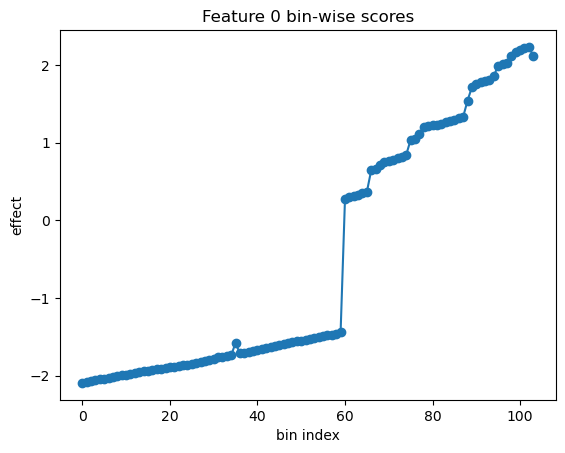

In [188]:
import matplotlib.pyplot as plt

plt.plot(scores, marker='o')
plt.title(f"Feature {idx} bin-wise scores")
plt.xlabel("bin index")
plt.ylabel("effect")
plt.show()

In [189]:
print("len(scores):", len(scores))
print("len(boundaries):", len(scores) + 1)

len(scores): 104
len(boundaries): 105


In [212]:
#A4
import numpy as np

i = 0
scores = np.array(term_scores[i])

density = np.ones_like(scores) / len(scores)

importance_manual = np.sum(np.abs(scores) * density)

print("importance:", importance_manual)

importance: 1.5329686052967297


In [223]:
#A5
import numpy as np
import pandas as pd
import os

ebm_global = ebm.explain_global().data()

names = ebm_global['names']
term_scores = ebm.term_scores_

In [225]:
def get_type(scores):
    return "num" if len(scores) > 10 else "cat"

def get_importance(scores):
    scores = np.array(scores)
    return np.mean(np.abs(scores))

def get_ci_width(scores):
    scores = np.array(scores)
    return 1.96 * np.std(scores)

In [226]:
rows = []

for i in range(len(names)):

    scores = np.array(term_scores[i])

    # safety check
    if scores is None or len(scores) == 0:
        continue

    rows.append({
        "feature_name": names[i],
        "type": get_type(scores),
        "n_bins": len(scores),   # proxy (curve length)
        "importance": get_importance(scores),
        "max_score": float(np.max(scores)),
        "min_score": float(np.min(scores)),
        "mean_ci_width": get_ci_width(scores)
    })

df = pd.DataFrame(rows)

In [227]:
df = df.sort_values("importance", ascending=False)

In [228]:
os.makedirs("output", exist_ok=True)

df.to_csv("output/W04_feature_summary.csv", index=False)

In [230]:
import shutil

shutil.move(
    "output/W04_feature_summary.csv",
    "../output/W04_feature_summary.csv"
)

'../output/W04_feature_summary.csv'